<div style="display:block;width:100%;margin:auto;" direction=rtl align=center><br><br>
    <div  style="width:100%;margin:100;display:block;background-color:#fff0;"  display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">
            <tr>
                <td  style="border: none!important;">
        <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                <h1 align=center><font size=5 color="#87CEEB"> <b>Introduction to Cognitive Science</b><br><br>HomeWork #2</i></font></h1>
            </td>
            <td style="border: none!important;">
        <img width=170 align=left  src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
            </td>
        </tr>
        </table>
    
</div>
<br>
<font size=3 color="#00FFFF"> Sina Pirmoradian : 810101125 <br></font><br>

<font color="#FA5F55"><h1>HW #2 Part #3</h2></font>

<font color="#F4BB44"><h3>Connect Google Drive</h3></font>

In [1]:
from google.colab import drive
drive.mount ('/content/drive')

Mounted at /content/drive


<font color="#F4BB44"><h3>Import Reqiured Library</h3></font>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

<font color="#F4BB44"><h3>Load the Data</h3></font>

In [3]:
# Load the time series data and labels from numpy files
data = np.load('/content/drive/MyDrive/Cognetive/HW_2/assignment2-face-data.npy')
labels = np.load('/content/drive/MyDrive/Cognetive/HW_2/assignment2-face-data-labels.npy')
print(labels.shape)

(77, 1)


<font color="#F4BB44"><h3>Moving Average through the Time</h3></font>

In [4]:
# Calculate firing rate using a moving average window of length 50
window_length = 50
str_ = 1

Moving_average = np.zeros((data.shape[0], data.shape[1], (data.shape[2] - window_length + 1)))
for i in range(data.shape[0]):
  for j in range(data.shape[1]):
    Moving_average[i,j] = np.convolve(data[i,j,:], np.ones(window_length)/window_length, mode='valid')[::str_]

<font color="#F4BB44"><h3>Visualization Moving Average through the Time</h3></font>

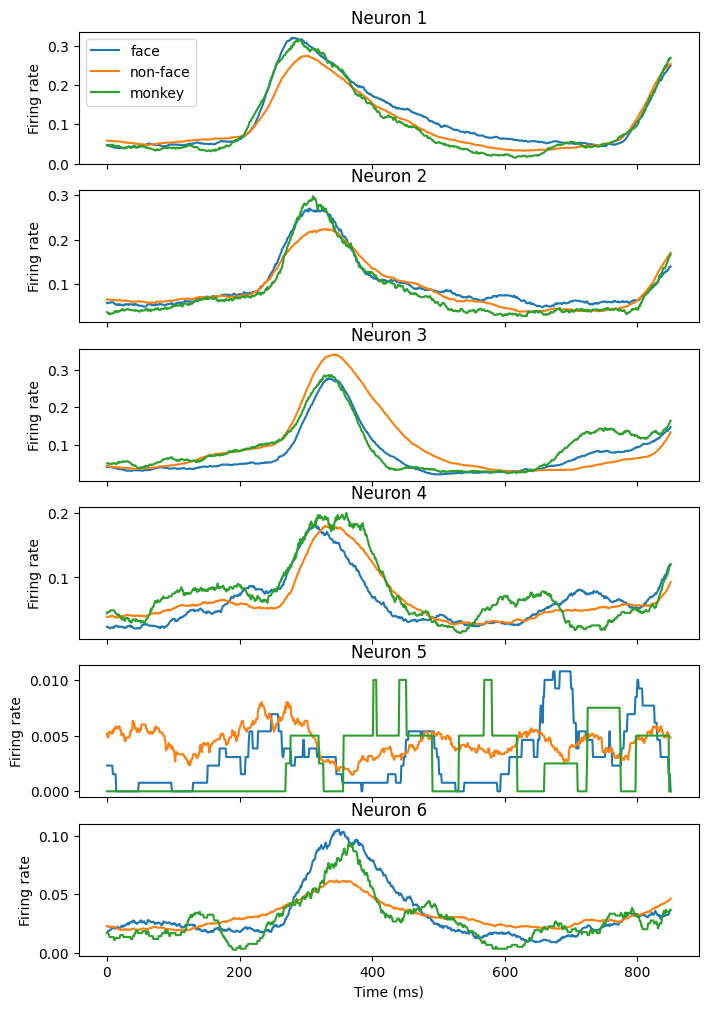

In [5]:
# Plot the time series of each neuron's response to face and non-face stimuli
fig, axs = plt.subplots(nrows=6, ncols=1, figsize=(8,12), sharex=True)
for i in range(6):
    face_trials = np.where(labels == 0)[0]
    nonface_trials = np.where(labels == 2)[0]
    monkey_trials = np.where(labels == 1)[0]
    axs[i].plot(np.mean(Moving_average[face_trials,i,:], axis=0), label='face')
    axs[i].plot(np.mean(Moving_average[nonface_trials,i,:], axis=0), label='non-face')
    axs[i].plot(np.mean(Moving_average[monkey_trials,i,:], axis=0), label='monkey')
    axs[i].set_ylabel('Firing rate')
    axs[i].set_title('Neuron {}'.format(i+1))
axs[0].legend()
plt.xlabel('Time (ms)')
plt.show()

<font color="#F4BB44"><h3>Calculate and Visualizing Firing Rate</h3></font>


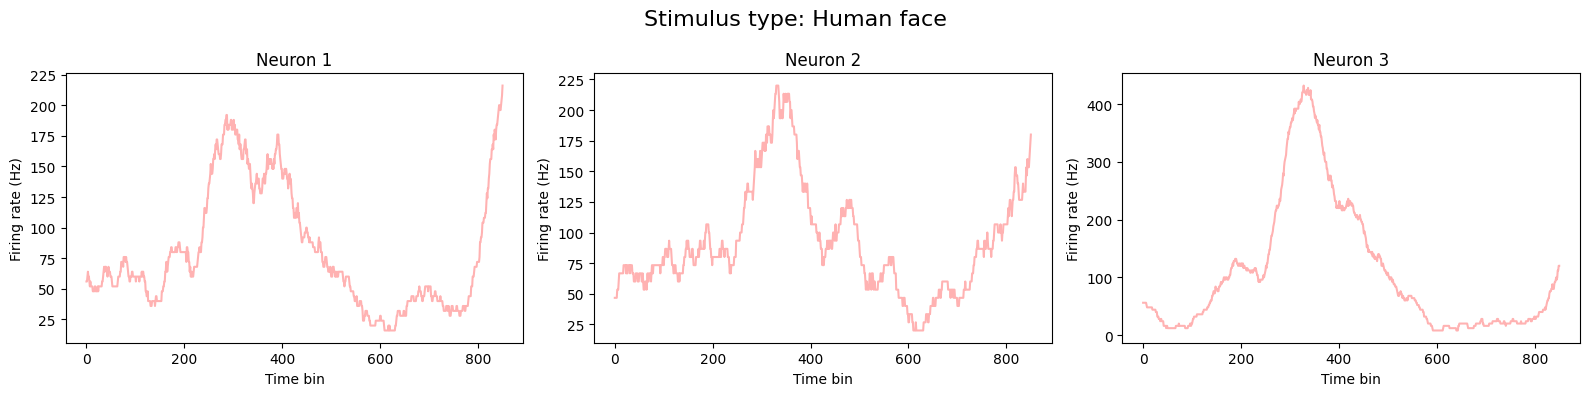

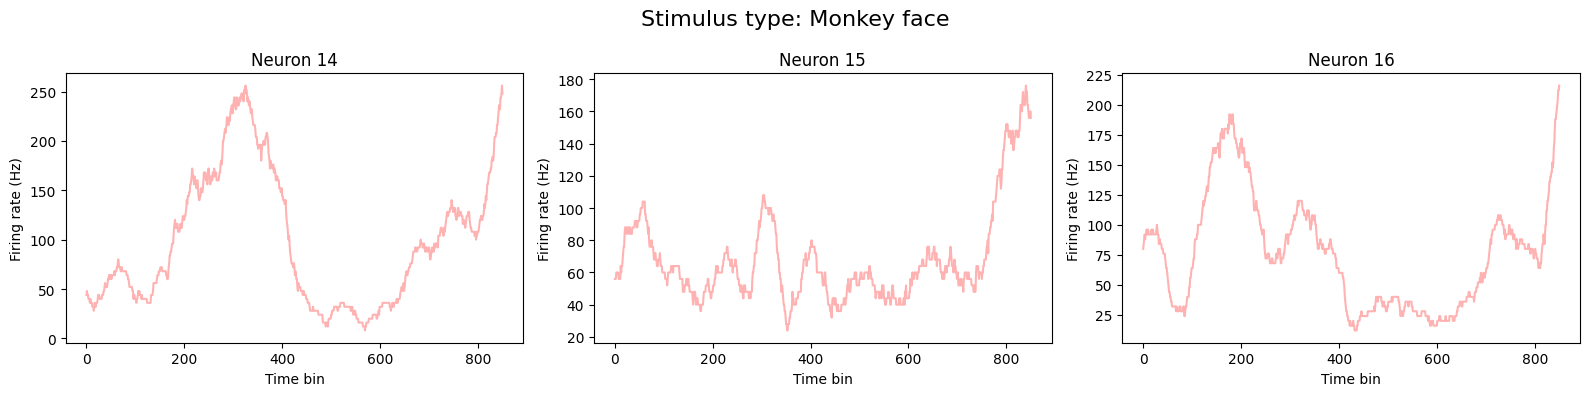

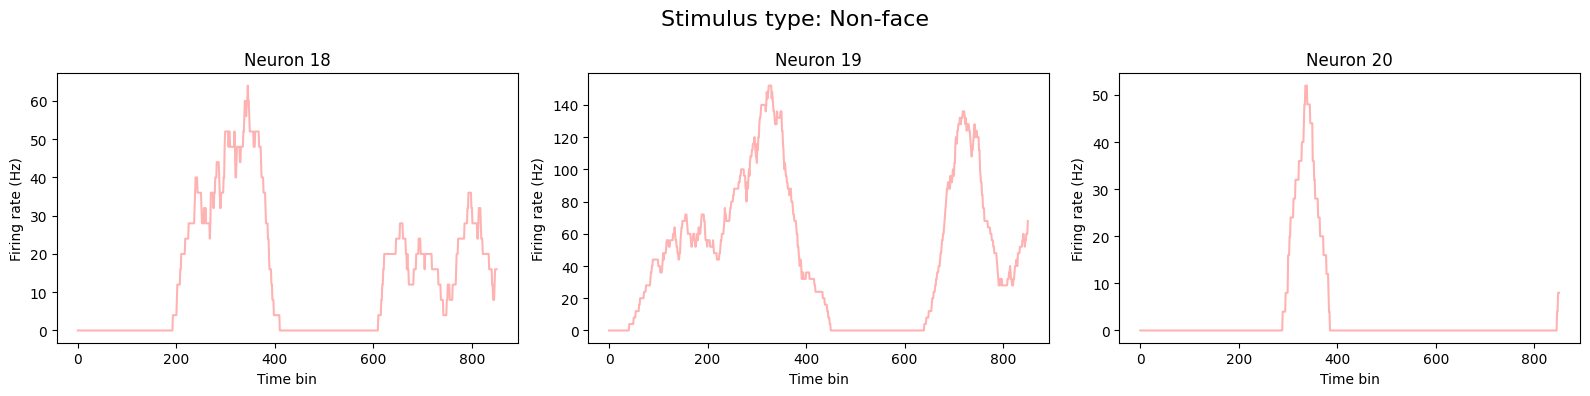

In [6]:
# Define the length and stride of the sliding window
window_len = 50
stride = 1

# Calculate the number of time bins
num_bins = int((data.shape[-1] - window_len) / stride) + 1

# Initialize an empty array to store the firing rates
firing_rates = np.zeros((len(labels), data.shape[1], num_bins))

# Loop over each trial and each neuron, and calculate the firing rates for each time bin
for i in range(len(labels)):
    for j in range(data.shape[1]):
        for k in range(num_bins):
            window_start = k * stride
            window_end = window_start + window_len
            num_spikes = np.sum(data[i, j, window_start:window_end])
            firing_rates[i, j, k] = num_spikes / window_len * 1000  # Convert to firing rate in Hz

# Plot the firing rates for each neuron, stratified by stimulus type
stimulus_types = ['Human face', 'Monkey face', 'Non-face']
num_neurons_per_stimulus = 3  # Modify this to change the number of neurons per stimulus to plot
for stimulus in range(3):
    num_neurons = np.sum(labels == stimulus)
    neuron_idx = np.where(labels == stimulus)[0][:num_neurons_per_stimulus]  # Select the first `num_neurons_per_stimulus` neurons
    num_cols = 3  # Set the number of columns to 3
    num_rows = 1  # Set the number of rows to 1
    fig, axs = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(16, 4))
    fig.suptitle(f'Stimulus type: {stimulus_types[stimulus]}', fontsize=16)
    for n, neuron in enumerate(neuron_idx):
        axs[n].plot(firing_rates[i, neuron, :].T, color='red', alpha=0.3)
        axs[n].set_title(f'Neuron {neuron+1}')
        axs[n].set_xlabel('Time bin')
        axs[n].set_ylabel('Firing rate (Hz)')
    plt.tight_layout()
    plt.show()


<font color="#F4BB44"><h3>Firing rate, Neuron activity for 3 class</h3></font>

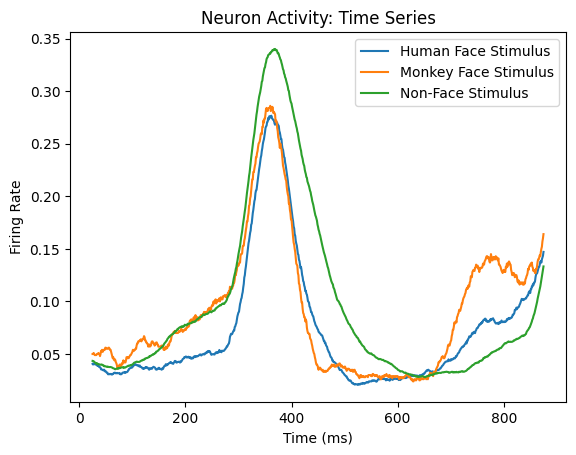

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Select a single neuron (neuron_index) and extract the spiking activity data
neuron_index = 2
neuron_data = data[:, neuron_index, :]

# Ensure that the labels array has the same shape as the number of observations/stimuli (77)
labels = np.load('/content/drive/MyDrive/Cognetive/HW_2/assignment2-face-data-labels.npy')[:77]
labels = labels.ravel()

# Split the data based on the stimulus labels
human_face_data = neuron_data[labels == 0]
monkey_face_data = neuron_data[labels == 1]
non_face_data = neuron_data[labels == 2]

# Calculate the firing rate by moving average window
window_length = 50
stride = 1

def calculate_firing_rate(data):
    num_trials, num_samples = data.shape
    firing_rate = np.zeros(num_samples - window_length + 1)
    for i in range(num_samples - window_length + 1):
        firing_rate[i] = np.mean(data[:, i:i+window_length])
    return firing_rate

human_face_firing_rate = calculate_firing_rate(human_face_data)
monkey_face_firing_rate = calculate_firing_rate(monkey_face_data)
non_face_firing_rate = calculate_firing_rate(non_face_data)

# Plot the time series of firing rate for each type of stimulus
time = np.arange(window_length//2, 900 - window_length//2 + 1)  # Adjust x-axis based on window length
plt.plot(time, human_face_firing_rate, label='Human Face Stimulus')
plt.plot(time, monkey_face_firing_rate, label='Monkey Face Stimulus')
plt.plot(time, non_face_firing_rate, label='Non-Face Stimulus')
plt.xlabel('Time (ms)')
plt.ylabel('Firing Rate')
plt.title('Neuron Activity: Time Series')
plt.legend()
plt.show()


<font color="#F4BB44"><h3>Calculating Mutual Information</h3></font>

In [14]:
from sklearn.feature_selection import mutual_info_classif as MIC
labels=labels.ravel()
mi_score = []
for i in range(40):
    mi_score.append(MIC(Moving_average[:, i, :],labels))

In [15]:
mi_score = np.array(mi_score)
print(mi_score.shape)

(40, 851)


In [16]:
means = np.array(mi_score).mean(axis=0)
stds = np.array(mi_score).std(axis=0)

means = pd.DataFrame(means).rolling(50, axis = 0).mean().dropna(axis=0).to_numpy().reshape(-1)
stds = pd.DataFrame(stds).rolling(50, axis = 0).mean().dropna(axis=0).to_numpy().reshape(-1)

In [17]:
print(means.shape)
print(stds.shape)

(802,)
(802,)


Text(0, 0.5, 'firing rate or Data_mean')

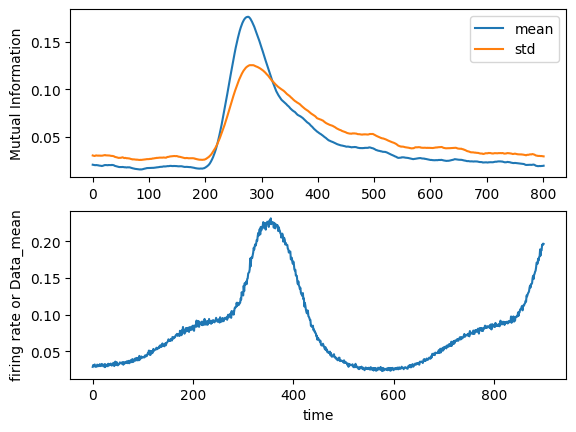

In [18]:
plt.subplot(2, 1, 1)
plt.plot(means, label='mean')
plt.plot(stds, label='std')
plt.legend()
plt.ylabel('Mutual Information')

plt.subplot(2, 1, 2)
plt.plot(data.mean(axis=1).mean(axis=0))
plt.xlabel('time')
plt.ylabel('firing rate or Data_mean')

<font color="#F4BB44"><h3>Bar Plot Error</h3></font>

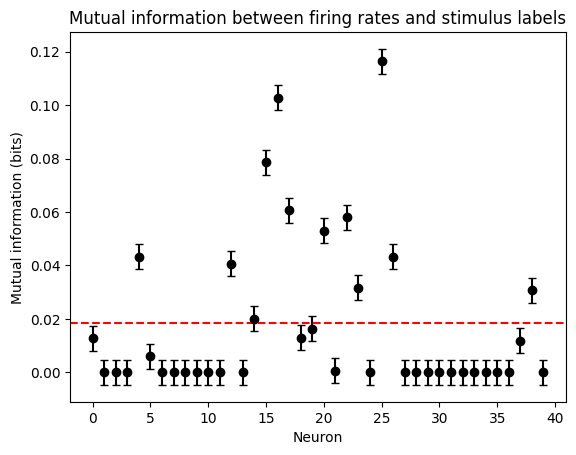

In [19]:
from sklearn.feature_selection import mutual_info_classif

# Define the length and stride of the sliding window
window_len = 50
stride = 1

# Calculate the number of time bins
num_bins = int((data.shape[-1] - window_len) / stride) + 1

# Initialize an empty array to store the firing rates
firing_rates = np.zeros((len(labels), data.shape[1], num_bins))

# Loop over each trial and each neuron, and calculate the firing rates for each time bin
for i in range(len(labels)):
    for j in range(data.shape[1]):
        for k in range(num_bins):
            window_start = k * stride
            window_end = window_start + window_len
            num_spikes = np.sum(data[i, j, window_start:window_end])
            firing_rates[i, j, k] = num_spikes / window_len * 1000  # Convert to firing rate in Hz

# Calculate the mutual information score for each neuron
mi_scores = np.zeros(data.shape[1])
for i in range(data.shape[1]):
    mi_scores[i] = mutual_info_classif(firing_rates[:, i, :], labels)[0]

# Plot the mutual information scores
mean_mi = np.mean(mi_scores)
sem_mi = np.std(mi_scores) / np.sqrt(len(mi_scores))
plt.errorbar(range(data.shape[1]), mi_scores, yerr=sem_mi, fmt='o', color='black', capsize=3)
plt.axhline(y=mean_mi, linestyle='--', color='red')
plt.xlabel('Neuron')
plt.ylabel('Mutual information (bits)')
plt.title('Mutual information between firing rates and stimulus labels')
plt.show()


<font color="#F4BB44"><h3>Calculate the mutual information for each time bin</h3></font>

In [20]:
# Calculate the mutual information for each time bin and each neuron
mi_scores = np.zeros((data.shape[1], num_bins))
for i in range(data.shape[1]):
    for j in range(num_bins):
        mi_scores[i, j] = mutual_info_classif(firing_rates[:, i, j].reshape(-1, 1), labels)[0]

# Calculate the mean and standard error of the mean of the mutual information across neurons
mi_mean = np.mean(mi_scores, axis=0)
mi_sem = np.std(mi_scores, axis=0) / np.sqrt(mi_scores.shape[0])

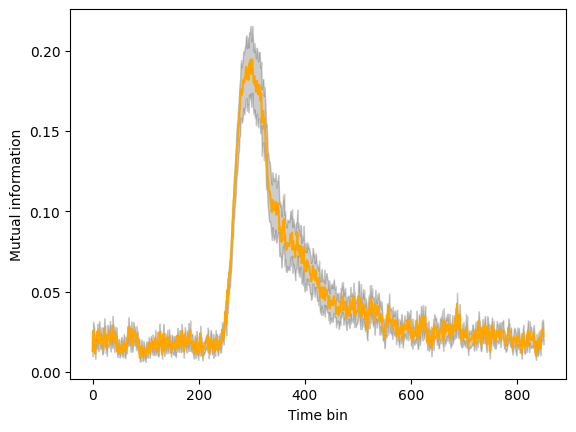

In [21]:
# Plot the mean and standard error of the mean of the mutual information
fig, ax = plt.subplots()
ax.plot(np.arange(num_bins), mi_mean, color='orange')
ax.fill_between(np.arange(num_bins), mi_mean - mi_sem, mi_mean + mi_sem, alpha=0.2, color='black')
ax.set_xlabel('Time bin')
ax.set_ylabel('Mutual information')
plt.show()

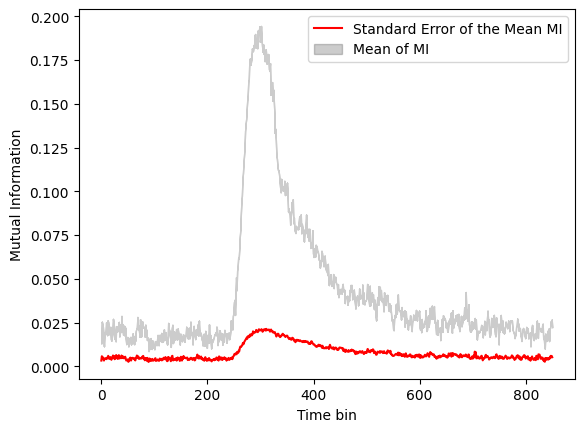

In [22]:
# Plot mean and the standard error of the mean of the mutual information
fig, ax = plt.subplots()
ax.plot(np.arange(num_bins), mi_sem, color='red', label='Standard Error of the Mean MI')
ax.fill_between(np.arange(num_bins), mi_mean, mi_mean, alpha=0.2, color='black', label='Mean of MI')
ax.set_xlabel('Time bin')
ax.set_ylabel('Mutual Information')
ax.legend()
plt.show()

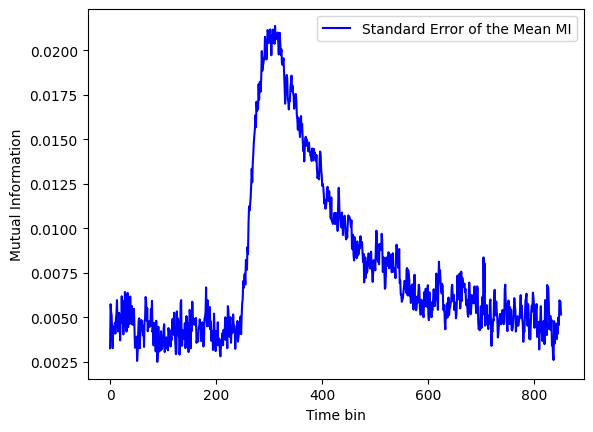

In [23]:
# Plot the standard error of the mean of the mutual information
fig, ax = plt.subplots()
ax.plot(np.arange(num_bins), mi_sem, color='Blue', label = 'Standard Error of the Mean MI')
ax.set_xlabel('Time bin')
ax.set_ylabel('Mutual Information')
ax.legend()
plt.show()

<font color="#F4BB44"><h3>Average the d-prime across neurons and plot the results</h3></font>

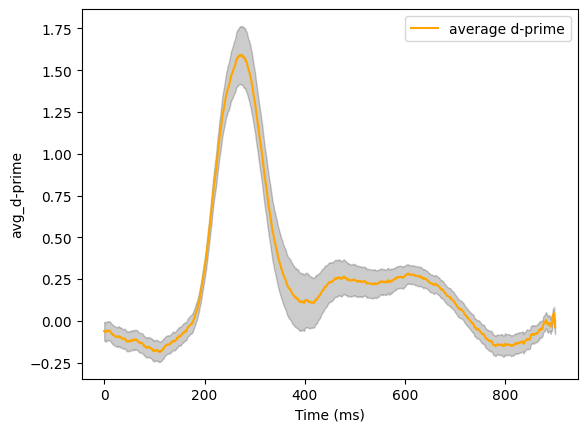

In [40]:
# Define window length and compute firing rates for each neuron and stimulus type
window_length = 100
num_obs, num_neurons, num_samples = data.shape
firing_rates = np.zeros((num_obs, num_neurons, num_samples))
for i in range(num_obs):
    for j in range(num_neurons):
        for k in range(num_samples):
            window = data[i, j, k:k+window_length]
            firing_rates[i, j, k] = np.sum(window) / window_length

# Calculate d-prime over time
d_prime = np.zeros((num_neurons, num_samples))
labels = labels.reshape((77,))
for j in range(num_neurons):
    for k in range(num_samples):   
        face_firing_rates = firing_rates[labels == 0, j, k]
        nonface_firing_rates = firing_rates[labels == 2, j, k]
        face_mean = np.mean(face_firing_rates)
        nonface_mean = np.mean(nonface_firing_rates)
        face_var = np.var(face_firing_rates)
        nonface_var = np.var(nonface_firing_rates)
        pooled_var = (face_var + nonface_var) / 2
        epsilon = 1e-6
        # d_prime[j, k] = (face_mean - nonface_mean) / np.sqrt(pooled_var)  + epsilon
        if pooled_var < epsilon:
            d_prime[j, k] = 0  # Set d-prime to 0 when the variance is too small
        else:
            d_prime[j, k] = (face_mean - nonface_mean) / np.sqrt(pooled_var) + epsilon

# Average d-prime across neurons and plot results
avg_d_prime = np.mean(d_prime, axis=0)
sem_d_prime = np.std(d_prime, axis=0) / np.sqrt(num_neurons)
plt.figure()
plt.plot(range(num_samples), avg_d_prime, label='average d-prime', color='orange')
plt.fill_between(range(num_samples), avg_d_prime - sem_d_prime, avg_d_prime + sem_d_prime, alpha=0.2, color='black')
plt.xlabel('Time (ms)')
plt.ylabel('avg_d-prime')
plt.legend()
plt.show()


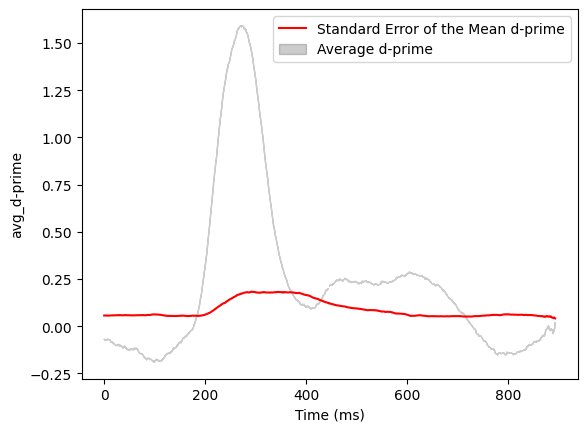

In [25]:
# Plot mean and the standard error of the mean of the d-prime
plt.figure()
plt.plot(range(num_samples), sem_d_prime, color='red', label='Standard Error of the Mean d-prime')
plt.fill_between(range(num_samples), avg_d_prime, avg_d_prime, alpha=0.2, color='black', label='Average d-prime')
plt.xlabel('Time (ms)')
plt.ylabel('avg_d-prime')
plt.legend()
plt.show()

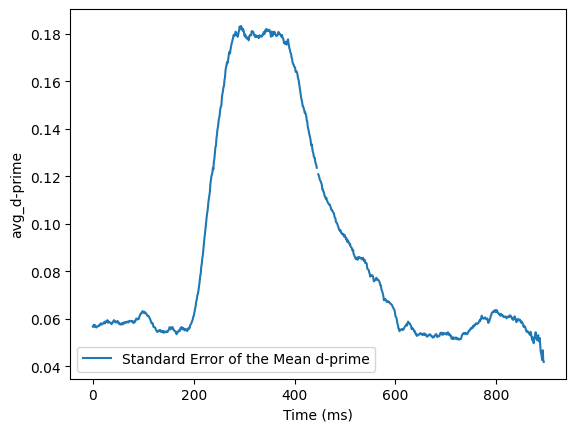

In [26]:
# Plot the standard error of the mean of the d-prime
plt.figure()
plt.plot(range(num_samples), sem_d_prime, label='Standard Error of the Mean d-prime')
plt.xlabel('Time (ms)')
plt.ylabel('avg_d-prime')
plt.legend()
plt.show()

<font color="#F4BB44"><h3>Compare Both Mutual information and average d-prime</h3></font>


Text(0, 0.5, 'firing rate')

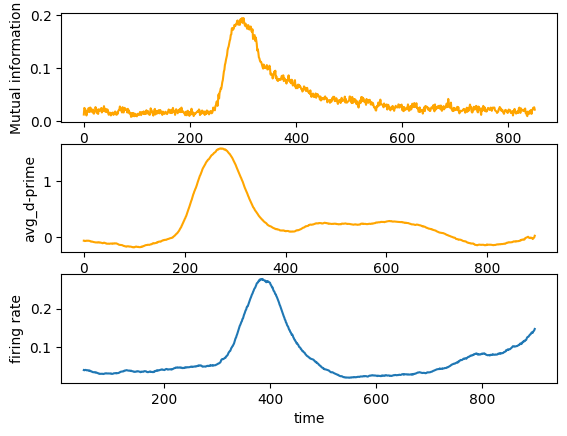

In [34]:
plt.subplot(3, 1, 1)
# Plot the mean and standard error of the mean of the mutual information
plt.plot(np.arange(num_bins), mi_mean, color='orange')
# plt.fill_between(np.arange(num_bins), mi_mean - mi_sem, mi_mean + mi_sem, alpha=0.2, color='black')
plt.xlabel('Time bin')
plt.ylabel('Mutual information')

plt.subplot(3, 1, 2)
# Average d-prime across neurons and plot results
plt.plot(range(num_samples), avg_d_prime, label='average d-prime', color='orange')
# plt.fill_between(range(num_samples), avg_d_prime - sem_d_prime, avg_d_prime + sem_d_prime, alpha=0.2, color='black')
plt.xlabel('Time (ms)')
plt.ylabel('avg_d-prime')

plt.subplot(3, 1, 3)
time = np.arange(window_length//2-1, 900 )  # Adjust x-axis based on window length
plt.plot(time, human_face_firing_rate, label='Human Face Stimulus')
plt.xlabel('time')
plt.ylabel('firing rate')

In [35]:
face_mean = Moving_average[np.where(labels!=2)[0]].mean(axis=0)
non_face_mean = Moving_average[np.where(labels==2)[0]].mean(axis=0)

face_std = Moving_average[np.where(labels!=2)[0]].std(axis=0)
non_face_std = Moving_average[np.where(labels==2)[0]].std(axis=0)

pooled_var = np.sqrt(face_std ** 2 + non_face_std ** 2)/2

epsilon = 1e-6
d_prime = (face_mean - non_face_mean) / (pooled_var + epsilon)

In [36]:
d_prime_means = pd.DataFrame(np.nanmean(d_prime, axis=0)).rolling(50, axis = 0).mean().dropna(axis=0).to_numpy().reshape(-1)
d_prime_std = pd.DataFrame(np.nanstd(d_prime, axis=0)).rolling(50, axis = 0).mean().dropna(axis=0).to_numpy().reshape(-1)

Text(0, 0.5, 'firing rate')

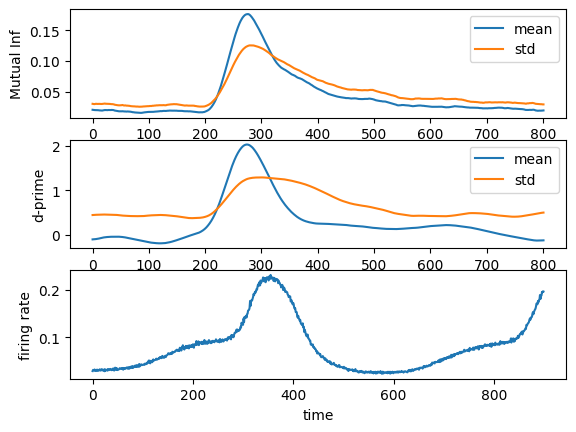

In [37]:
plt.subplot(3, 1, 1)
plt.plot(means, label='mean')
plt.plot(stds, label='std')
plt.legend()
plt.ylabel('Mutual Inf')

plt.subplot(3, 1, 2)
plt.plot(d_prime_means, label='mean')
plt.plot(d_prime_std, label='std')
plt.legend()
plt.ylabel('d-prime')

plt.subplot(3, 1, 3)
plt.plot(data.mean(axis=1).mean(axis=0))
plt.xlabel('time')
plt.ylabel('firing rate')



<font color="#F4BB44"><h3>Compare Both the onset and peak timings of the Mutual information and average d-prime</h3></font>


In [41]:
# Define window length and compute firing rates for each neuron and stimulus type
window_length = 100
num_obs, num_neurons, num_samples = data.shape
firing_rates = np.zeros((num_obs, num_neurons, num_samples))
for i in range(num_obs):
    for j in range(num_neurons):
        for k in range(num_samples):
            window = data[i, j, k:k+window_length]
            firing_rates[i, j, k] = np.sum(window) / window_length

# Calculate the mutual information for each time bin and each neuron
mi_scores = np.zeros((num_neurons, num_samples))
for j in range(num_neurons):
    for k in range(num_samples):
        mi_scores[j, k] = mutual_info_classif(firing_rates[:, j, k].reshape(-1, 1), labels)[0]

# Calculate d-prime over time
d_prime = np.zeros((num_neurons, num_samples))
labels = labels.reshape((77,))
for j in range(num_neurons):
    for k in range(num_samples):
        face_firing_rates = firing_rates[labels == 0, j, k]
        nonface_firing_rates = firing_rates[labels == 2, j, k]
        face_mean = np.mean(face_firing_rates)
        nonface_mean = np.mean(nonface_firing_rates)
        face_var = np.var(face_firing_rates)
        nonface_var = np.var(nonface_firing_rates)
        pooled_var = (face_var + nonface_var) / 2
        epsilon = 1e-6
        # d_prime[j, k] = (face_mean - nonface_mean) / np.sqrt(pooled_var) + epsilon
        if pooled_var < epsilon:
            d_prime[j, k] = 0  # Set d-prime to 0 when the variance is too small
        else:
            d_prime[j, k] = (face_mean - nonface_mean) / np.sqrt(pooled_var) + epsilon
# Calculate the threshold as the mean plus one standard deviation
threshold = np.mean(d_prime) + np.std(d_prime)

# Find the onset and peak timings of d-prime, mutual information, and firing rate
onset_dprime = np.argmax(d_prime > threshold)
peak_dprime = np.argmax(d_prime)
onset_mi = np.argmax(mi_scores > threshold)
peak_mi = np.argmax(mi_scores)
onset_firing_rate = np.argmax(firing_rates)
peak_firing_rate = np.argmax(np.max(firing_rates, axis=2))

print("Onset timing - d-prime:", onset_dprime)
print("Peak timing - d-prime:", peak_dprime)
print("Onset timing - mutual information:", onset_mi)
print("Peak timing - mutual information:", peak_mi)
print("Onset timing - firing rate:", onset_firing_rate)
print("Peak timing - firing rate:", peak_firing_rate)



Onset timing - d-prime: 201
Peak timing - d-prime: 10179
Onset timing - mutual information: 0
Peak timing - mutual information: 11077
Onset timing - firing rate: 595220
Peak timing - firing rate: 661
